Mean cross-sectional area reduction post-stroke: 14.8%
Tortuosity index - Normal: 1.004 | Post-Stroke: 1.128


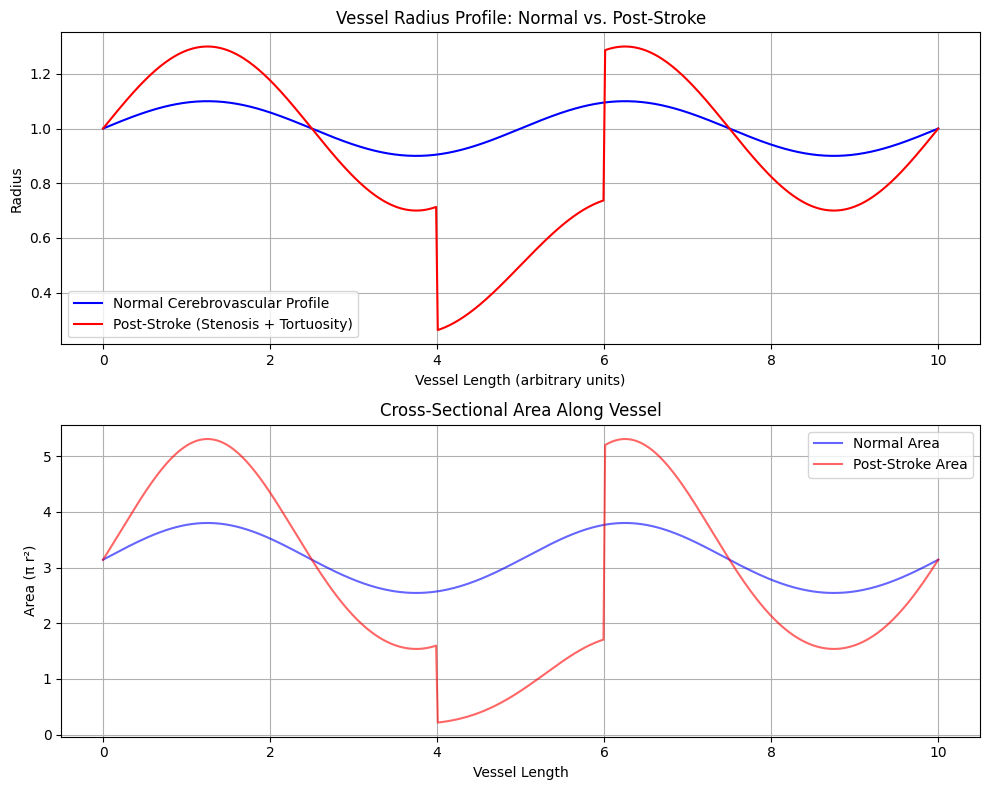

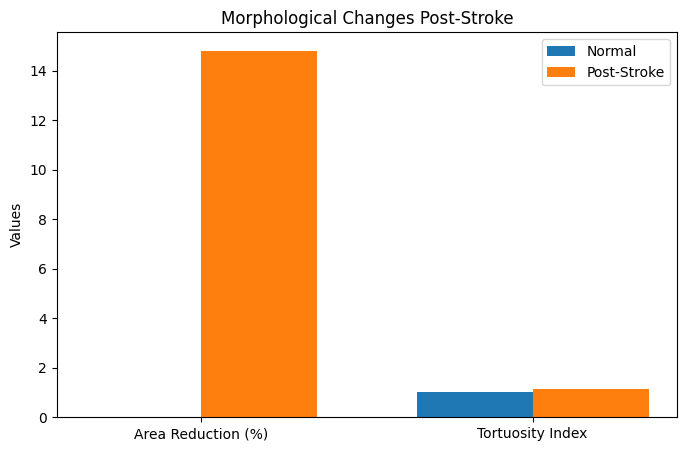

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for vessel length and base radius
L = 10.0  # Vessel length (arbitrary units, e.g., mm)
x = np.linspace(0, L, 500)

# Normal vessel: sinusoidal for mild natural curvature (proxy for cerebral artery)
radius_normal = 1.0 + 0.1 * np.sin(2 * np.pi * x / (L / 2))  # Base radius ~1 unit

# Post-stroke vessel: add stenosis (narrowing) in middle segment + increased tortuosity
radius_stroke = radius_normal.copy()
# Stenosis: reduce radius by 50% in central region
stenosis_start, stenosis_end = int(len(x)*0.4), int(len(x)*0.6)
radius_stroke[stenosis_start:stenosis_end] *= 0.5
# Add extra tortuosity (wavier path) post-stroke
tortuosity_factor = 0.2
radius_stroke += tortuosity_factor * np.sin(4 * np.pi * x / L)  # Higher frequency waves

# Compute key metrics
area_normal = np.pi * radius_normal**2
area_stroke = np.pi * radius_stroke**2
area_reduction_pct = 100 * (1 - np.mean(area_stroke / area_normal))

# Simple tortuosity index (arc length / straight length approximation)
def tortuosity(r):
    ds = np.sqrt(np.diff(x)**2 + np.diff(r)**2)
    return np.sum(ds) / L if len(ds) > 0 else 1.0

tort_normal = tortuosity(radius_normal)
tort_stroke = tortuosity(radius_stroke)

print(f"Mean cross-sectional area reduction post-stroke: {area_reduction_pct:.1f}%")
print(f"Tortuosity index - Normal: {tort_normal:.3f} | Post-Stroke: {tort_stroke:.3f}")

# Visualization: Vessel profiles
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

axs[0].plot(x, radius_normal, label='Normal Cerebrovascular Profile', color='blue')
axs[0].plot(x, radius_stroke, label='Post-Stroke (Stenosis + Tortuosity)', color='red')
axs[0].set_title("Vessel Radius Profile: Normal vs. Post-Stroke")
axs[0].set_xlabel("Vessel Length (arbitrary units)")
axs[0].set_ylabel("Radius")
axs[0].legend(); axs[0].grid(True)

axs[1].plot(x, area_normal, label='Normal Area', color='blue', alpha=0.6)
axs[1].plot(x, area_stroke, label='Post-Stroke Area', color='red', alpha=0.6)
axs[1].set_title("Cross-Sectional Area Along Vessel")
axs[1].set_xlabel("Vessel Length"); axs[1].set_ylabel("Area (π r²)")
axs[1].legend(); axs[1].grid(True)

plt.tight_layout()
plt.show()

# Bonus: Simple bar plot for metrics
metrics = ['Area Reduction (%)', 'Tortuosity Index']
values_normal = [0, tort_normal]  # Baseline 0% reduction
values_stroke = [area_reduction_pct, tort_stroke]
x_pos = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x_pos - width/2, values_normal, width, label='Normal')
ax.bar(x_pos + width/2, values_stroke, width, label='Post-Stroke')
ax.set_ylabel('Values')
ax.set_title('Morphological Changes Post-Stroke')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
plt.show()